In [1]:
  ! wget https://www.lancaster.ac.uk/scc/sites/lora/lorasim-20170710.tgz
  ! tar -xvf lorasim-20170710.tgz

  !sudo apt-get install python2 && curl https://bootstrap.pypa.io/pip/2.7/get-pip.py -o get-pip.py && python2 get-pip.py && rm get-pip.py
  !sudo apt install python-tk
  !pip2 install -r 'lorasim/requirements.txt'


--2025-04-26 17:22:35--  https://www.lancaster.ac.uk/scc/sites/lora/lorasim-20170710.tgz
Resolving www.lancaster.ac.uk (www.lancaster.ac.uk)... 148.88.65.80, 2001:630:80:2ff::80:1
Connecting to www.lancaster.ac.uk (www.lancaster.ac.uk)|148.88.65.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 112640 (110K) [application/x-gzip]
Saving to: ‘lorasim-20170710.tgz’

lorasim-20170710.tg 100%[===================>] 110.00K   274KB/s    in 0.4s    

2025-04-26 17:22:36 (274 KB/s) - ‘lorasim-20170710.tgz’ saved [112640/112640]

lorasim/
lorasim/loraDir.py
lorasim/loraDirMulBS.py
lorasim/oneDirectionalLoraIntf.py
lorasim/requirements.txt
lorasim/directionalLoraIntf.py
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libpython2-stdlib libpython2.7-minimal libpython2.7-stdlib python2-minimal
  python2.7 python2.7-minimal
Suggested packages:
  python2-doc python-tk pyth

In [4]:
import os
import pandas as pd
import math

In [3]:
import subprocess

def simulate(n_nodes, tx_rate, exp, duration):
    env = os.environ.copy()
    env["MPLBACKEND"] = "Agg"

    result = subprocess.run(
        [
            "python2",
            "lorasim/loraDir.py",
            str(int(n_nodes)),
            str(int(tx_rate)),
            str(int(exp)),
            str(int(duration)),
        ],
        env=env,
        capture_output=True,
        text=True,
    )

    print(f"[SIM] Nodes={n_nodes}, EXP={exp}")
    print("[STDOUT]\n", result.stdout)
    print("[STDERR]\n", result.stderr)


# Der in aloha defined as S/G = e^(-2G)
def aloha_der(n_nodes,t):
    rate = 1e-6
    return math.exp(-2 * n_nodes * rate * t)


In [5]:
duration = 86400000
tx_rate = 1e6
!rm -f exp0.dat exp2.dat exp4.dat exp5.dat exp3.dat
node_list = list(range(1,10)) + list(range(10,300,10)) + list(range(300,1700,100))

for n_nodes in node_list:
    # Original experiments (SN1/SN2/SN3)
    simulate(n_nodes, tx_rate, 0, duration)  # SN1
    simulate(n_nodes, tx_rate, 2, duration)  # SN2
    simulate(n_nodes, tx_rate, 4, duration)  # SN3

    # Additional experiments with dynamic parameters (SN4/SN5)
    simulate(n_nodes, tx_rate, 5, duration)  # SN4 (Dynamic minimum airtime)
    simulate(n_nodes, tx_rate, 3, duration)  # SN5 (Dynamic minimum airtime + power)


流式输出内容被截断，只能显示最后 5000 行内容。
CHECK node 1397 (sf:8 bw:500 freq:8.600000e+08) others: 1
>> node 959 (sf:8 bw:500 freq:8.600000e+08)
frequency coll 500
collision sf node 1397 and node 959
CHECK node 612 (sf:8 bw:500 freq:8.600000e+08) others: 1
>> node 1205 (sf:7 bw:500 freq:8.600000e+08)
frequency coll 500
no sf collision
CHECK node 1411 (sf:7 bw:500 freq:8.600000e+08) others: 1
>> node 911 (sf:8 bw:500 freq:8.600000e+08)
frequency coll 500
no sf collision
CHECK node 482 (sf:7 bw:500 freq:8.600000e+08) others: 1
>> node 1195 (sf:8 bw:500 freq:8.600000e+08)
frequency coll 500
no sf collision
CHECK node 1242 (sf:7 bw:500 freq:8.600000e+08) others: 1
>> node 827 (sf:7 bw:500 freq:8.600000e+08)
frequency coll 500
collision sf node 1242 and node 827
CHECK node 1495 (sf:7 bw:500 freq:8.600000e+08) others: 1
>> node 1503 (sf:7 bw:500 freq:8.600000e+08)
frequency coll 500
collision sf node 1495 and node 1503
CHECK node 180 (sf:7 bw:500 freq:8.600000e+08) others: 1
>> node 203 (sf:7 bw:500 freq:8.

In [6]:
data = pd.read_csv("exp0.dat", sep=" ")
data2 = pd.read_csv("exp2.dat", sep=" ")
data4 = pd.read_csv("exp4.dat", sep=" ")
data5 = pd.read_csv("exp5.dat", sep=" ")
data3 = pd.read_csv("exp3.dat", sep=" ")


In [7]:
data["der"] = (data["nrTransmissions"] - data["nrCollisions"]) / data["nrTransmissions"]
data["der_aloha"] = data["#nrNodes"].apply(lambda x: aloha_der(x,t=1712)) #7.07 1712 1318.91
data2["der"] = (data2["nrTransmissions"] - data2["nrCollisions"]) / data2["nrTransmissions"]
data4["der"] = (data4["nrTransmissions"] - data4["nrCollisions"]) / data4["nrTransmissions"]
data5["der"] = (data5["nrTransmissions"] - data5["nrCollisions"]) / data5["nrTransmissions"]
data3["der"] = (data3["nrTransmissions"] - data3["nrCollisions"]) / data3["nrTransmissions"]

Index(['#nrNodes', 'nrCollisions', 'nrTransmissions', 'OverallEnergy', 'der',
       'der_aloha'],
      dtype='object')
#nrNodes             int64
nrCollisions         int64
nrTransmissions      int64
OverallEnergy      float64
der                float64
dtype: object


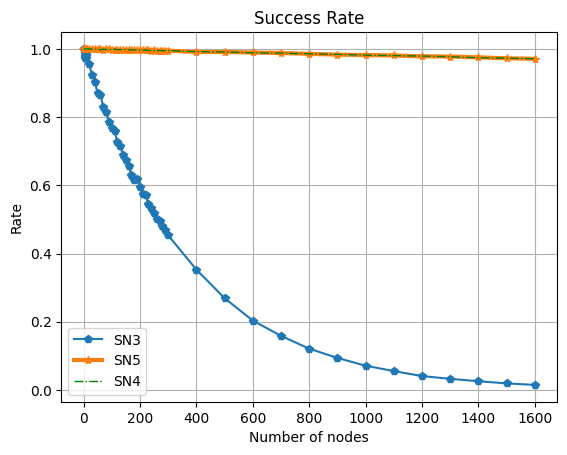

In [9]:
import matplotlib
import matplotlib.pyplot as plt
print(data.columns)
data["der"] = 1 - (data["nrCollisions"] / data["nrTransmissions"])

print(data4.dtypes)
# plt.plot(data["#nrNodes"], data["der_aloha"], 's-', label="Aloha")
# plt.plot(data["#nrNodes"], data["der"], '*-', label="SN0")
# plt.plot(data2["#nrNodes"], data2["der"], 'o-', label="SN2")
# plt.plot(data4["#nrNodes"], data4["der"], 'p-', label="SN4")
data4 = data4.sort_values(by="#nrNodes")  #
plt.plot(data4["#nrNodes"], data4["der"], 'p-', label="SN3")
plt.plot(data5["#nrNodes"], data5["der"], marker='*', linestyle='-', linewidth=3, label="SN5")


plt.plot(data3["#nrNodes"], data3["der"], color='green', linewidth=1, linestyle='-.', label="SN4")
plt.title("Success Rate")
plt.xlabel("Number of nodes")
plt.ylabel("Rate")
plt.legend()
plt.grid()
plt.show()